In [1]:
import pandas as pd
from plotnine import *

colors_dict = {
"SCoNE":"#2f4b7c",
"MVBC":"#665191",
"RGWAS":"#a05195",  
"C-NMF":"#d45087",  
"C-CoNE":"#f95d6a",  
"G-NMF":"#ff7c43",  
"G-CoNE":"#ffa600",  
"HNMF":"#2ca02c",  
"SCoNE(Fro)":"#1f77b4",
"CoNE":"#17becf"
}

# Assess runs over correlation
noise=0, sparsity=0, weight=0.5

In [11]:
def graph_plots(summary,variable_name,x_axis_name,y_axis_name,facet_by_factor_matrix=True,comparator_method_plot=True):
    # variable name is true var name, x-axis name is specific name for x-axis label (like if need latex)
    # if facet_by_factor_matrix is True, facet_wrap by factor matrix else don't
    # baseline methods
    p = (
        ggplot(summary[summary['run_name'].isin(['G-NMF','C-NMF','G-CoNE','C-CoNE','CoNE','SCoNE','SCoNE(Fro)','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
        + geom_point(size=2)
        + geom_line()
        + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
        + scale_color_manual(values=colors_dict)
        + labs(y=y_axis_name,x=x_axis_name)
        + theme_bw()
    )
    if facet_by_factor_matrix:
        p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
    else:
        p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
    print(p)

    # comparator methods
    if comparator_method_plot:
        p = (
            ggplot(summary[summary['run_name'].isin(['SCoNE','RGWAS','MVBC','HNMF'])], aes(variable_name, "mean", color='run_name', group='run_name'))
            + geom_point(size=2)
            + geom_line()
            + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
            + scale_color_manual(values=colors_dict)
            + labs(y=y_axis_name,x=x_axis_name)
            + theme_bw()
            + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        )
        if facet_by_factor_matrix:
            p = p + facet_wrap('factor_matrix', nrow=1) + theme(legend_title=element_text(size=9),figure_size=(8,4),legend_position='top')
        else:
            p = p + theme(legend_title=element_text(size=9),figure_size=(4,4),legend_position='top')
        print(p)

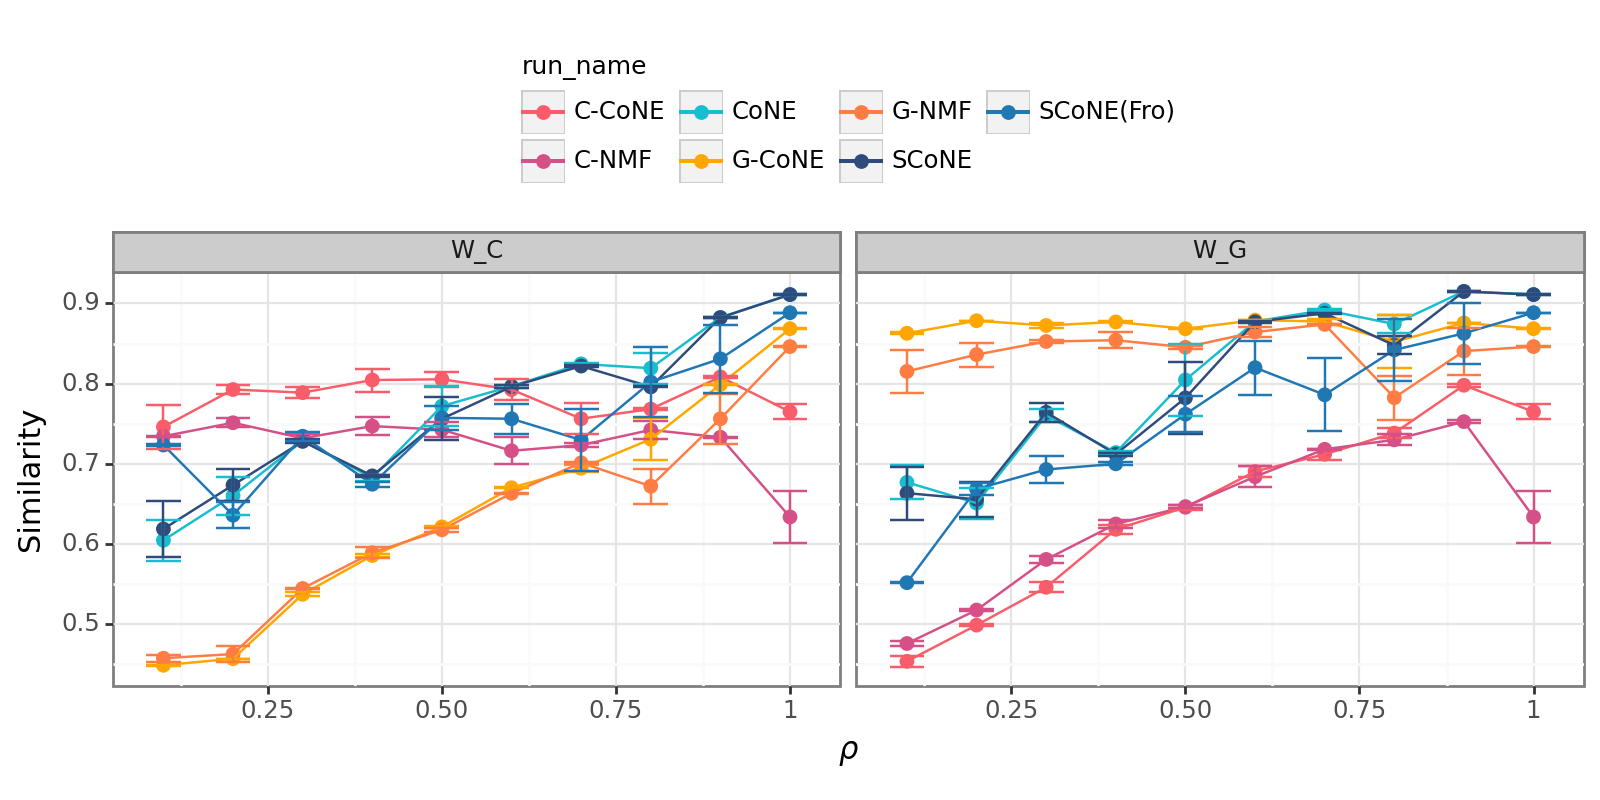

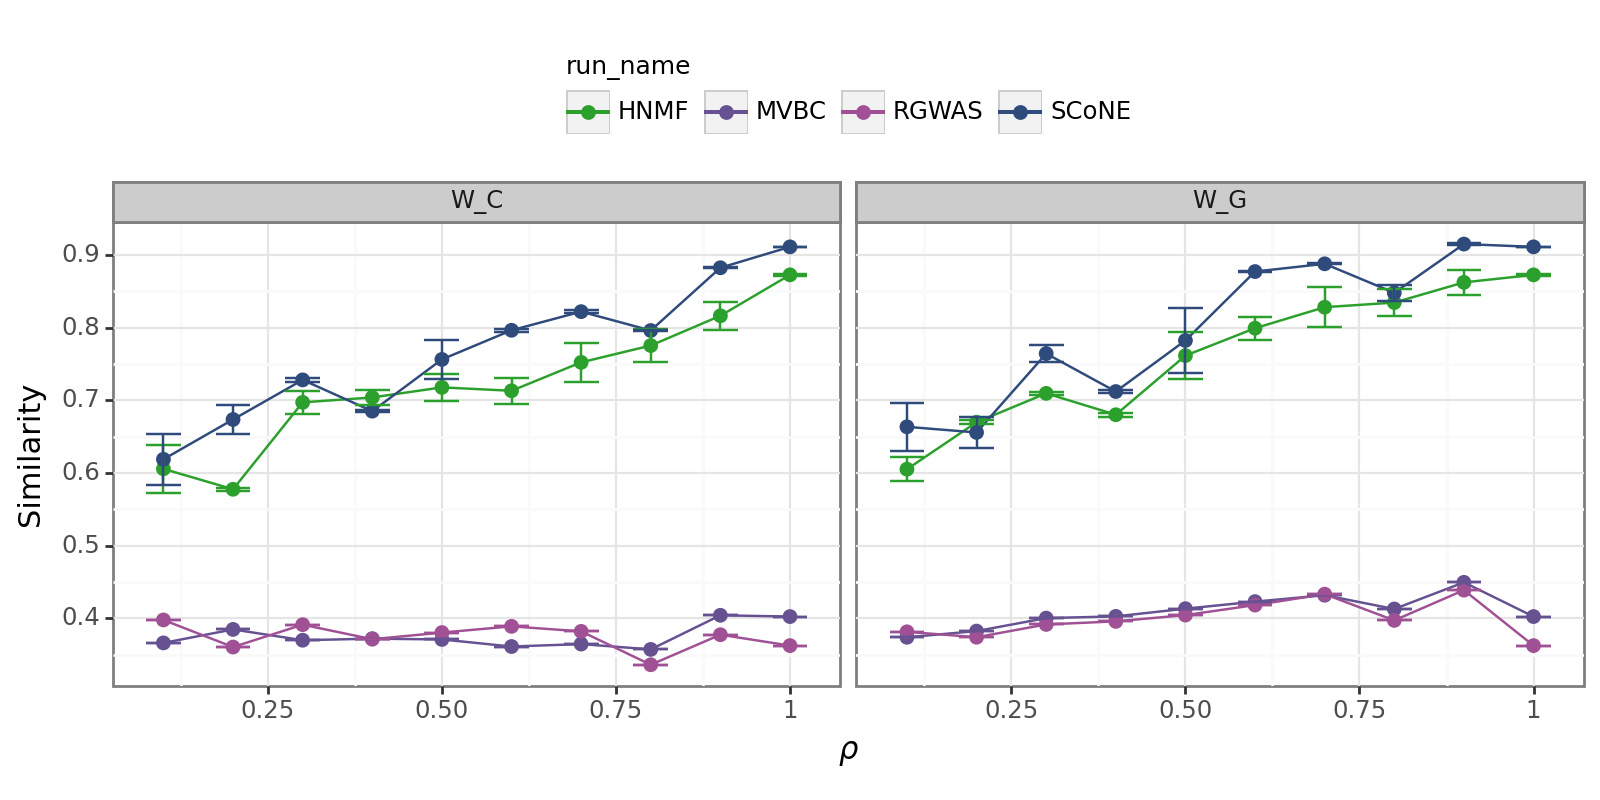

In [3]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary_sim.csv',index_col=0)
graph_plots(summary[summary['factor_matrix'].str.startswith('W')],"rho",y_axis_name="Similarity",x_axis_name=r"$\rho$")

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 20 rows containing missing values.


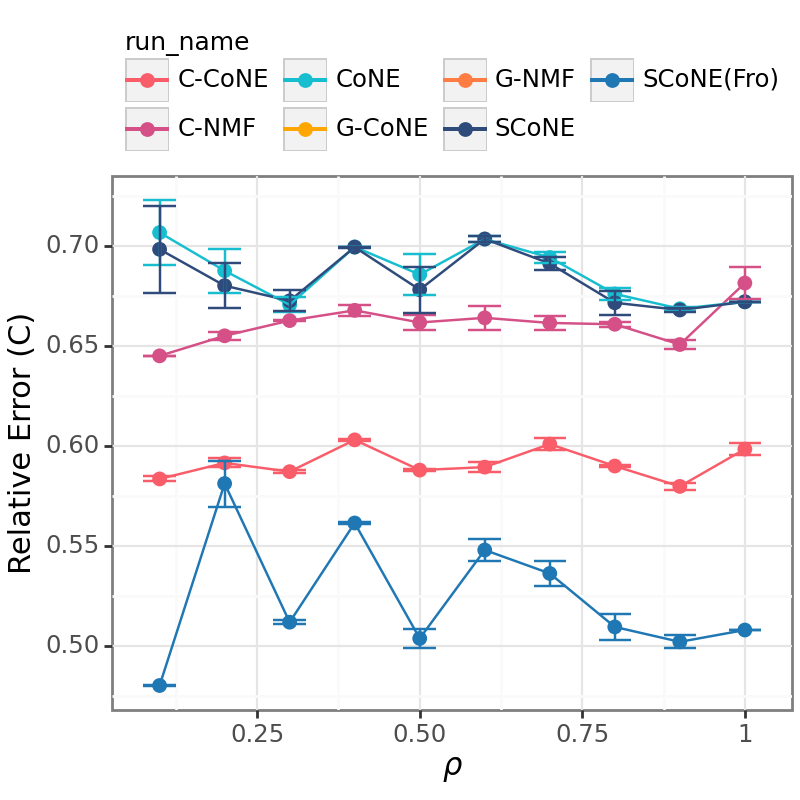

In [4]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary_rel_error_C.csv',index_col=0)
graph_plots(summary,"rho",y_axis_name="Relative Error (C)",x_axis_name=r"$\rho$",facet_by_factor_matrix=False,comparator_method_plot=False)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 20 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 20 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 20 rows containing missing values.


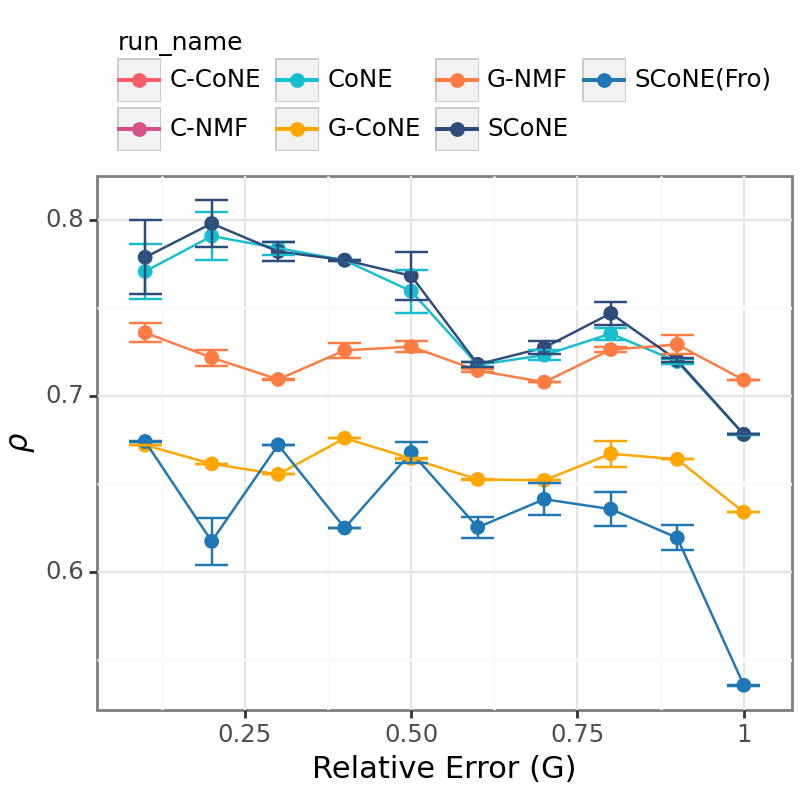

In [5]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/rho_summary_rel_error_G.csv',index_col=0)
graph_plots(summary,"rho","Relative Error (G)",r"$\rho$",facet_by_factor_matrix=False,comparator_method_plot=False)

# Assess runs over ZU weight

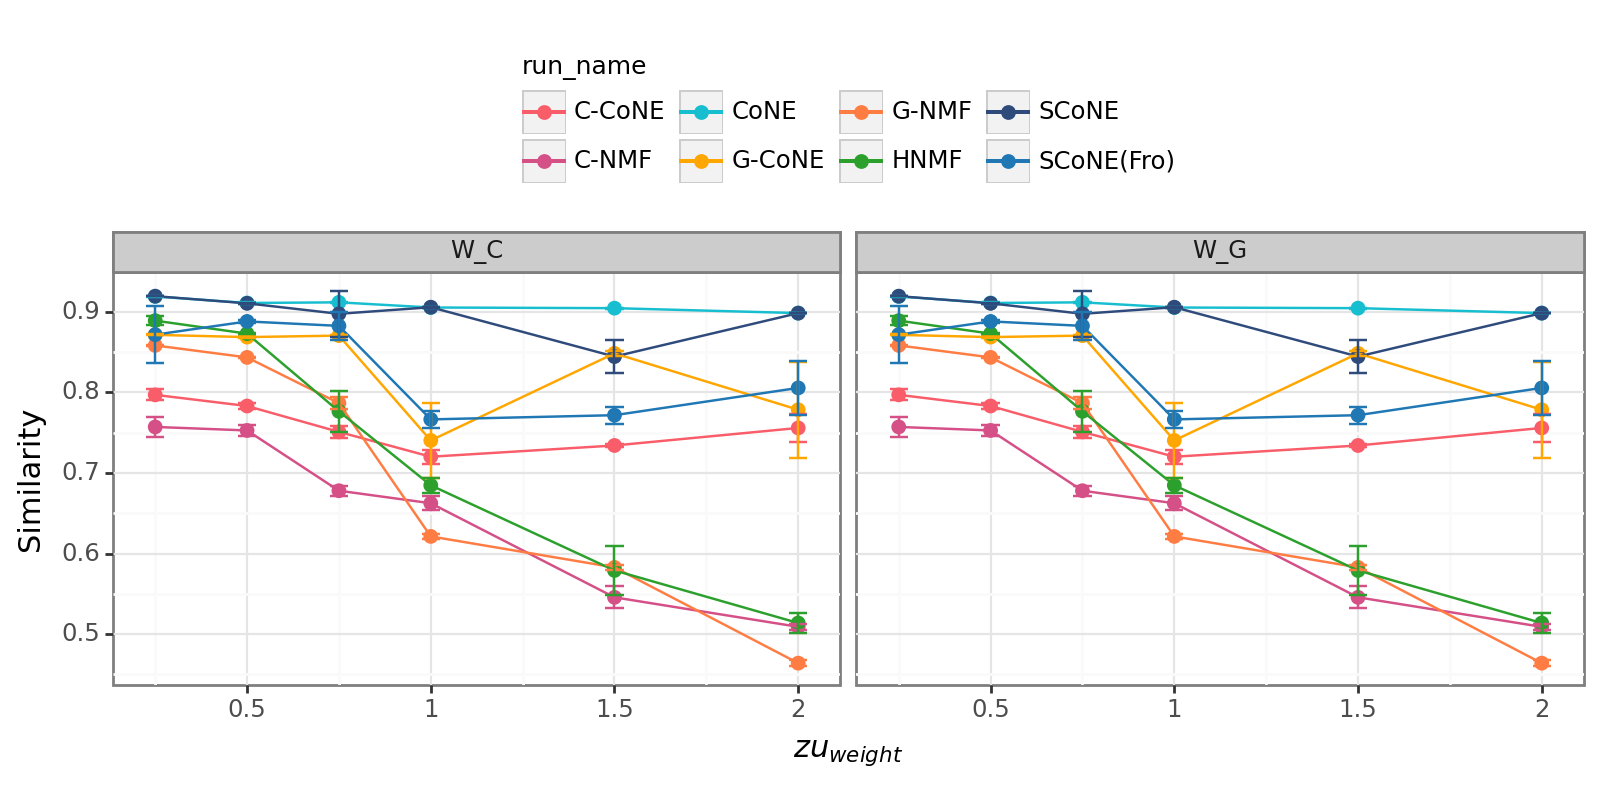

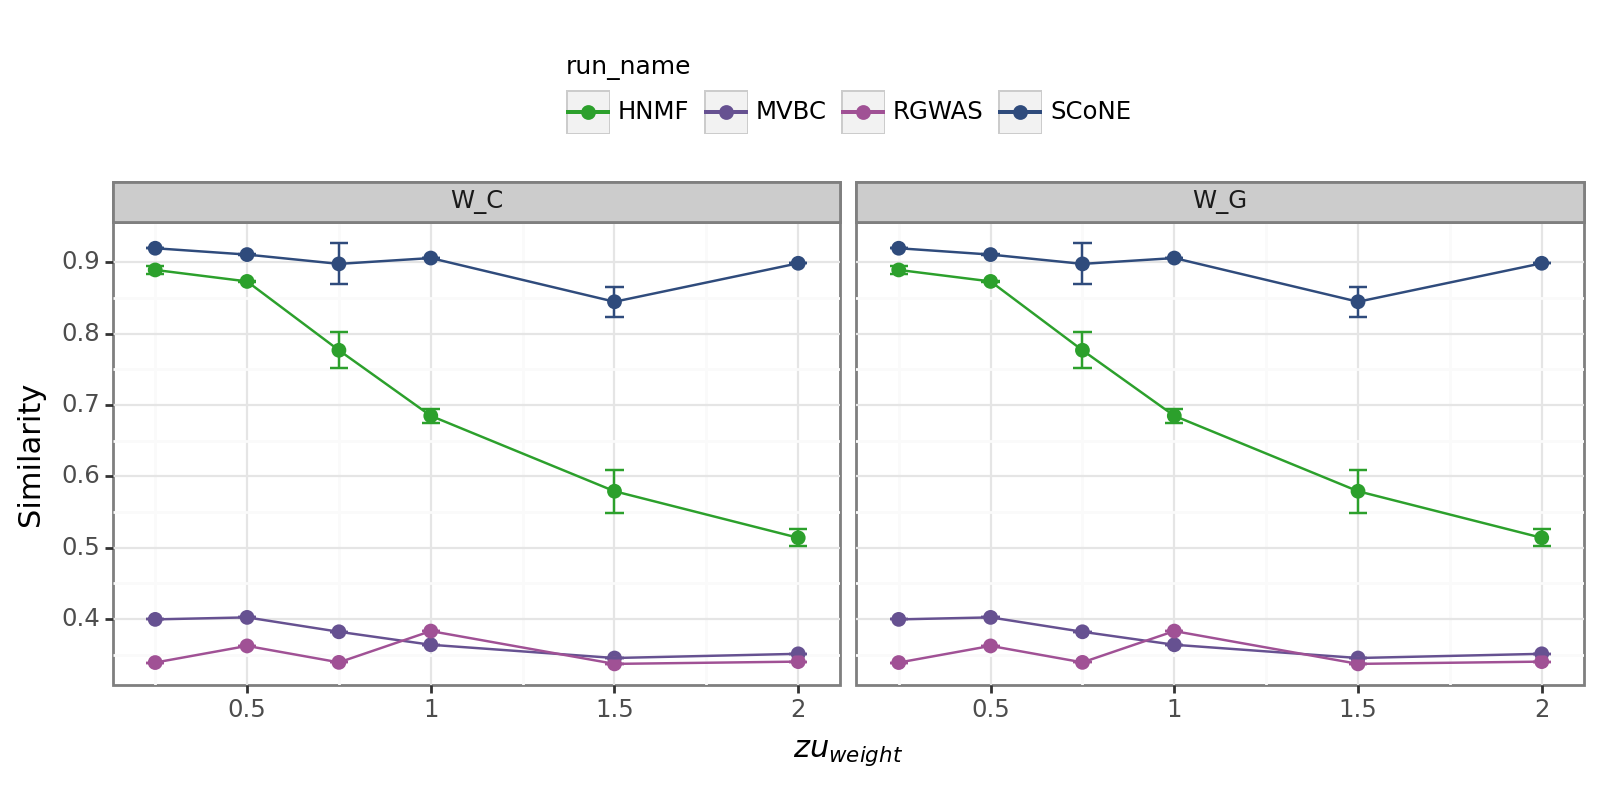

In [12]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_sim.csv',index_col=0)
graph_plots(summary[summary['factor_matrix'].str.startswith('W')],"ZU_weight",y_axis_name="Similarity",x_axis_name=r"$zu_{weight}$")

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 12 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 12 rows containing missing values.


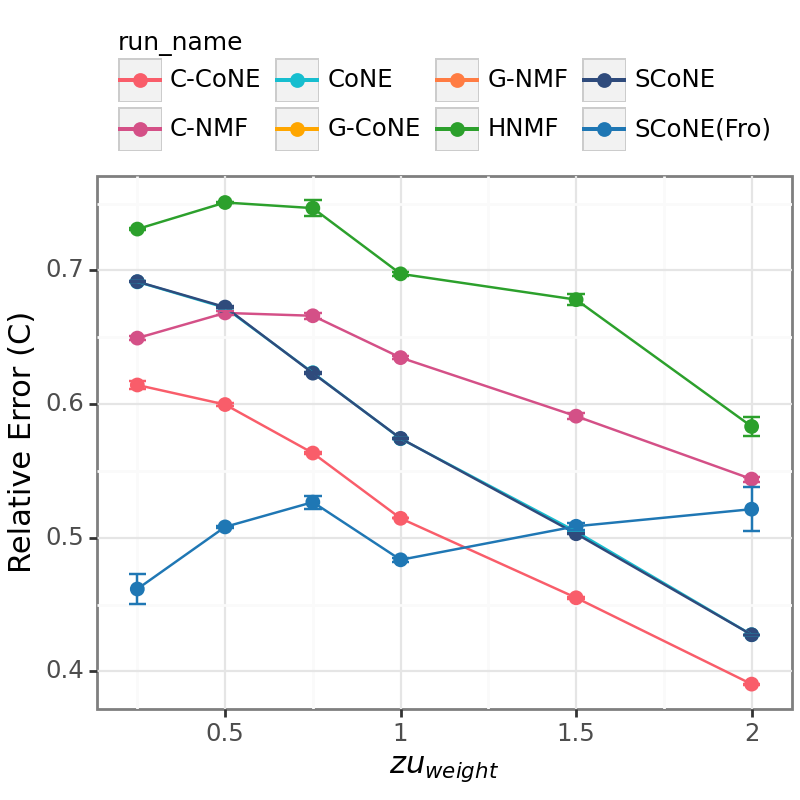

In [13]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_rel_error_C.csv',index_col=0)
graph_plots(summary,"ZU_weight",y_axis_name="Relative Error (C)",x_axis_name=r"$zu_{weight}$",facet_by_factor_matrix=False,comparator_method_plot=False)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 12 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 12 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 12 rows containing missing values.


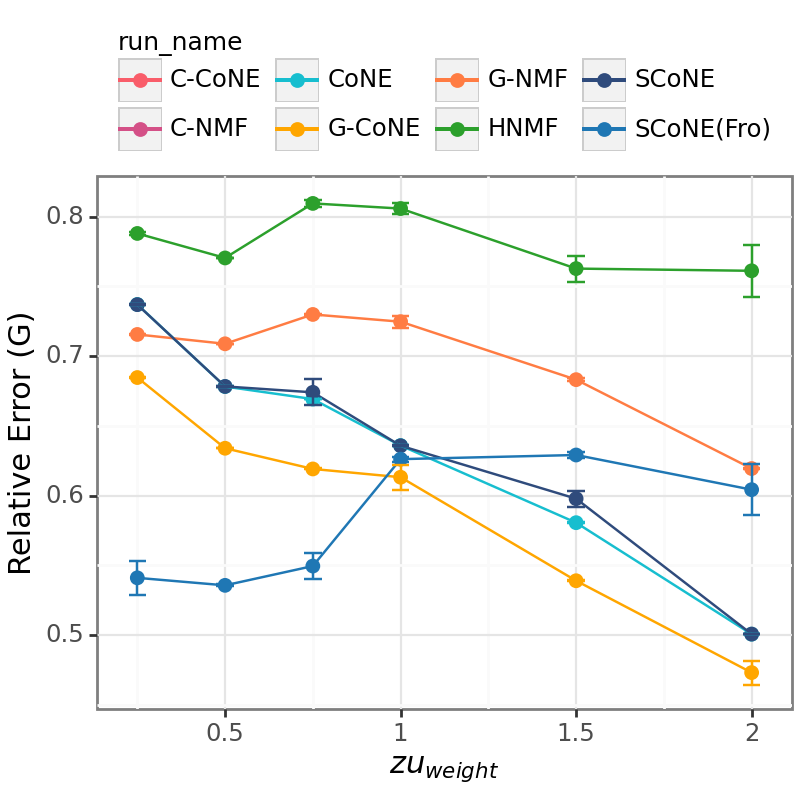

In [14]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/ZU_weight_summary_rel_error_G.csv',index_col=0)
graph_plots(summary,"ZU_weight",y_axis_name="Relative Error (G)",x_axis_name=r"$zu_{weight}$",facet_by_factor_matrix=False,comparator_method_plot=False)

# Assess runs over noise

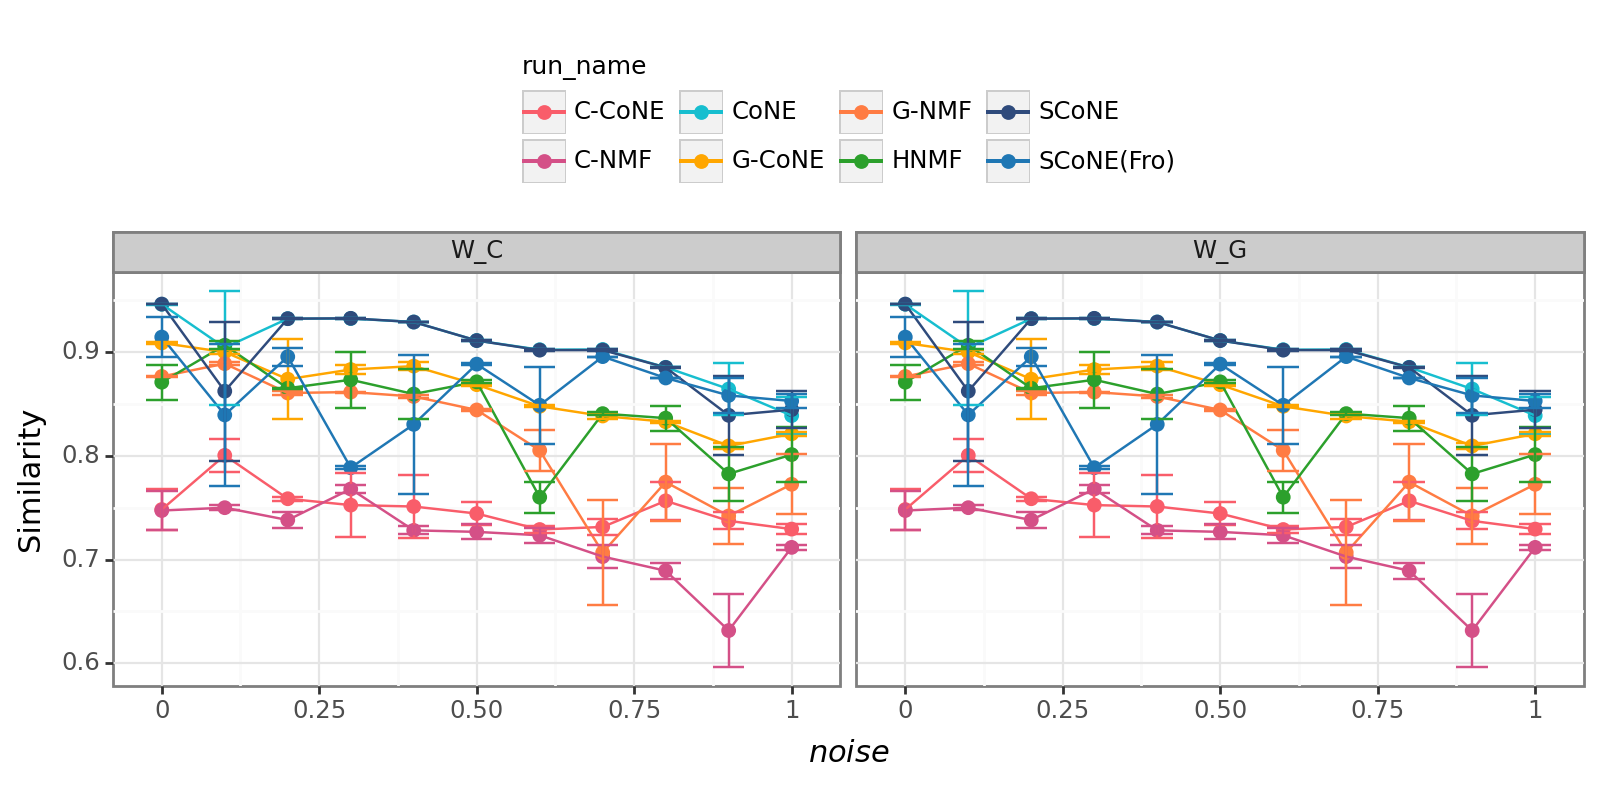

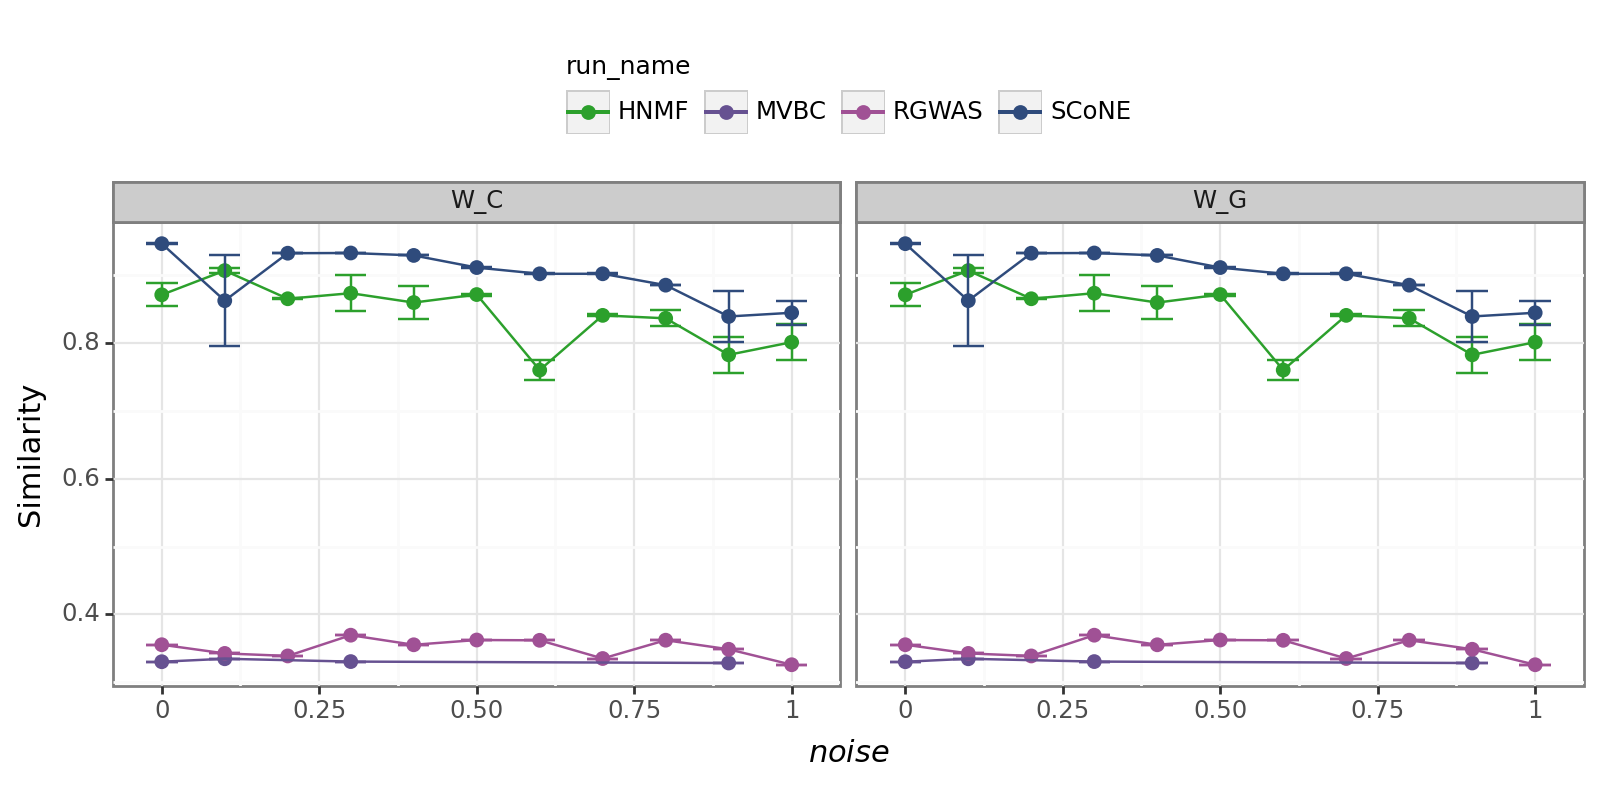

In [15]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary_sim.csv',index_col=0)
graph_plots(summary[summary['factor_matrix'].str.startswith('W')],"noise",y_axis_name="Similarity",x_axis_name=r"$noise$")

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 22 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 22 rows containing missing values.


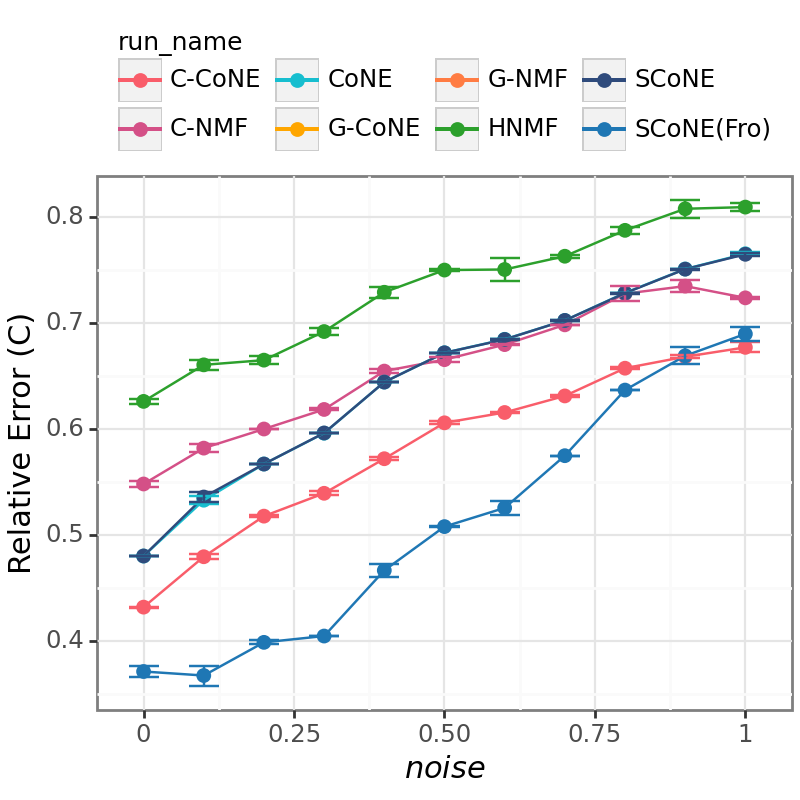

In [17]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary_rel_error_C.csv',index_col=0)
graph_plots(summary,"noise",y_axis_name="Relative Error (C)",x_axis_name=r"$noise$",facet_by_factor_matrix=False,comparator_method_plot=False)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_point : Removed 22 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/geoms/geom_path.py:98: PlotnineWarning: geom_path: Removed 22 rows containing missing values.
/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 22 rows containing missing values.


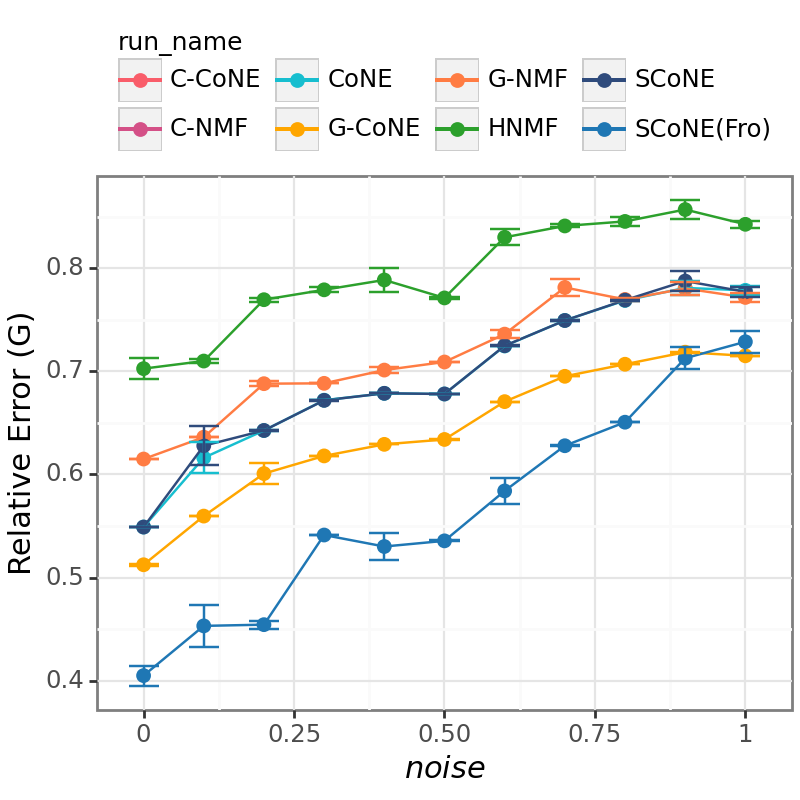

In [18]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/noise_summary_rel_error_G.csv',index_col=0)
graph_plots(summary,"noise",y_axis_name="Relative Error (G)",x_axis_name=r"$noise$",facet_by_factor_matrix=False,comparator_method_plot=False)

# Assess runs over sparsity

In [24]:
summary['run_name'].unique()

array(['C-CoNE_0.0', 'C-NMF_0.0', 'CoNE_0.0', 'G-CoNE_0.0', 'G-NMF_0.0',
       'HNMF_0.0', 'MVBC_0.0', 'MVBC_1e-06', 'MVBC_1e-05', 'MVBC_0.0001',
       'MVBC_0.001', 'MVBC_0.01', 'MVBC_0.1', 'MVBC_1.0', 'RGWAS_0.0',
       'SCoNE_0.0', 'SCoNE_1e-06', 'SCoNE_1e-05', 'SCoNE_0.0001',
       'SCoNE_0.001', 'SCoNE_0.01', 'SCoNE_0.1', 'SCoNE_1.0',
       'SCoNE_10.0', 'SCoNE_100.0', 'SCoNE(Fro)_0.0', 'SCoNE(Fro)_1e-06',
       'SCoNE(Fro)_1e-05', 'SCoNE(Fro)_0.0001', 'SCoNE(Fro)_0.001',
       'SCoNE(Fro)_0.01', 'SCoNE(Fro)_0.1', 'SCoNE(Fro)_1.0',
       'SCoNE(Fro)_10.0', 'SCoNE(Fro)_100.0'], dtype=object)

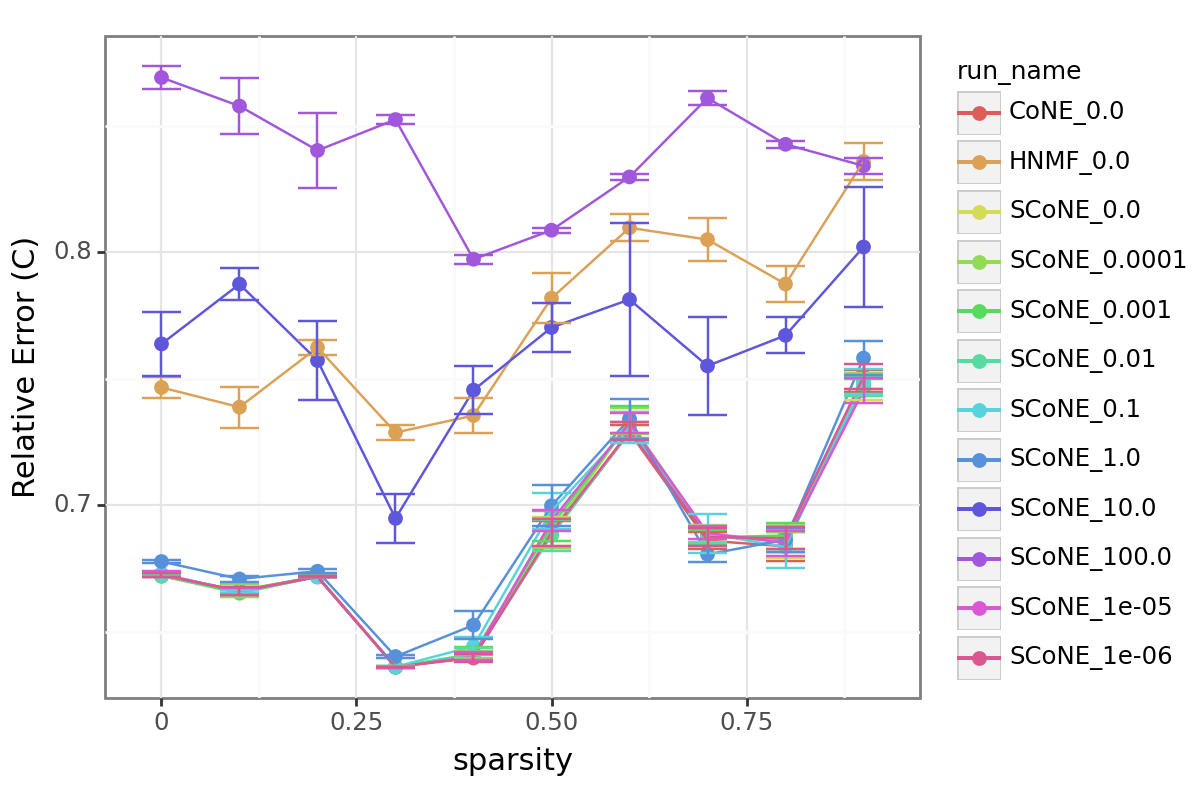

In [27]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_rel_error_C.csv',index_col=0)
summary = summary[summary['run_name'].isin(['SCoNE','HNMF','CoNE'])]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary, aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + labs(y="Relative Error (C)",x="sparsity")
    + theme_bw()
)
p = p + theme(legend_title=element_text(size=9),figure_size=(6,4))
print(p)

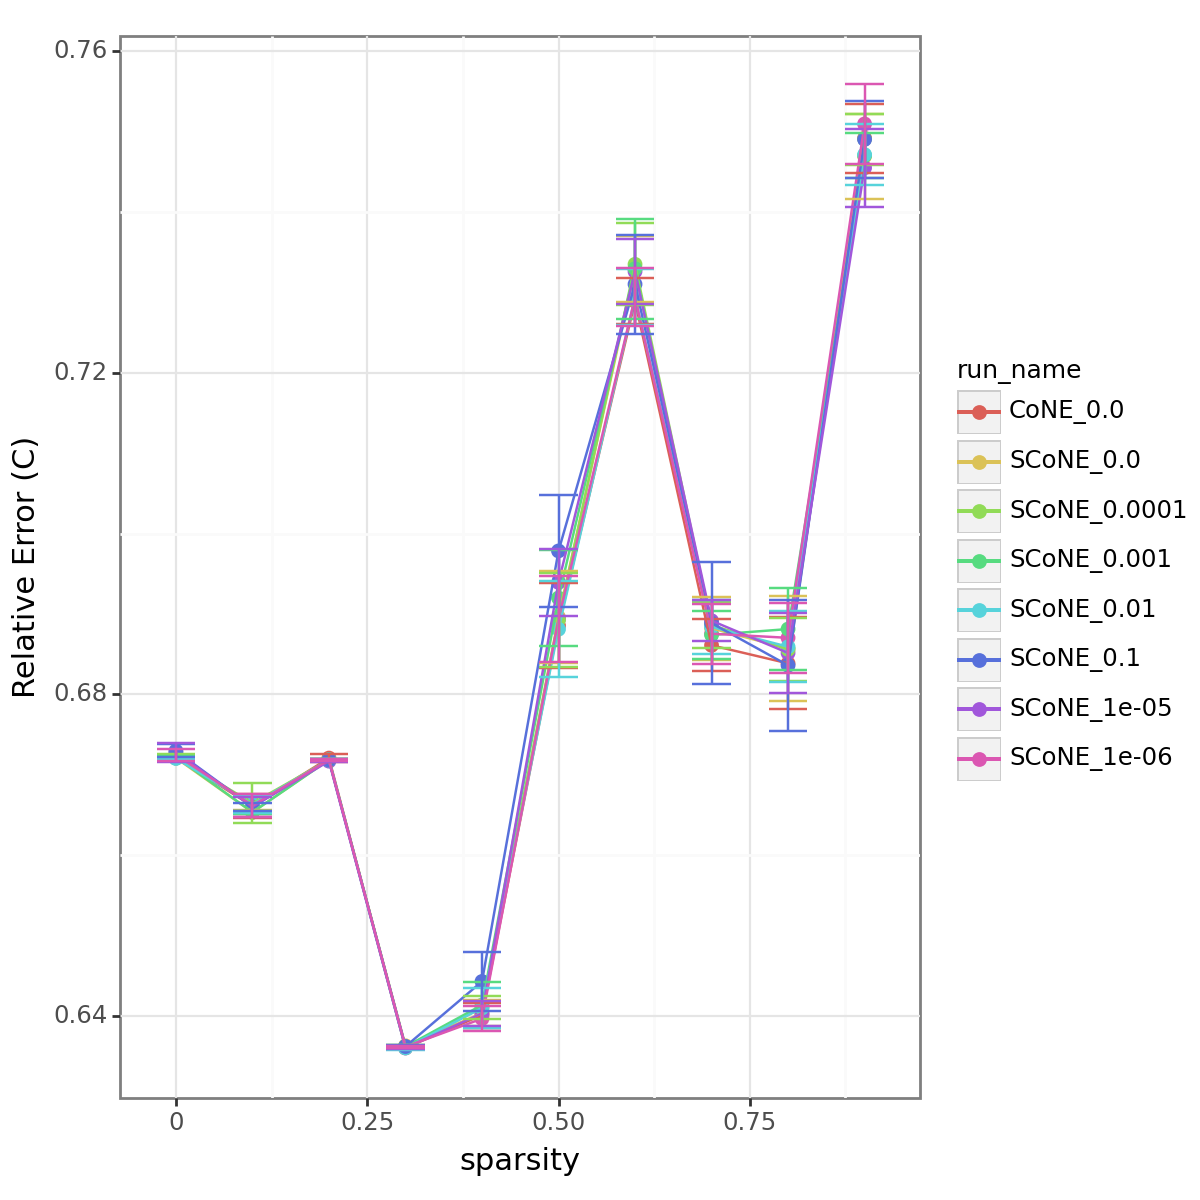

In [29]:
summary = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_summary_rel_error_C.csv',index_col=0)
summary = summary[(summary['run_name'].isin(['SCoNE','CoNE']))&(summary['lambda_H_G']<1)]
summary['run_name'] = summary.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']), axis=1)
p = (
    ggplot(summary, aes("sparsity", "mean", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + geom_errorbar(aes(ymin="ymin",ymax="ymax"),width=0.05)
    + labs(y="Relative Error (C)",x="sparsity")
    + theme_bw()
)
p = p + theme(legend_title=element_text(size=9),figure_size=(6,6))
print(p)

This plot for H_G and H_C tells the story we want

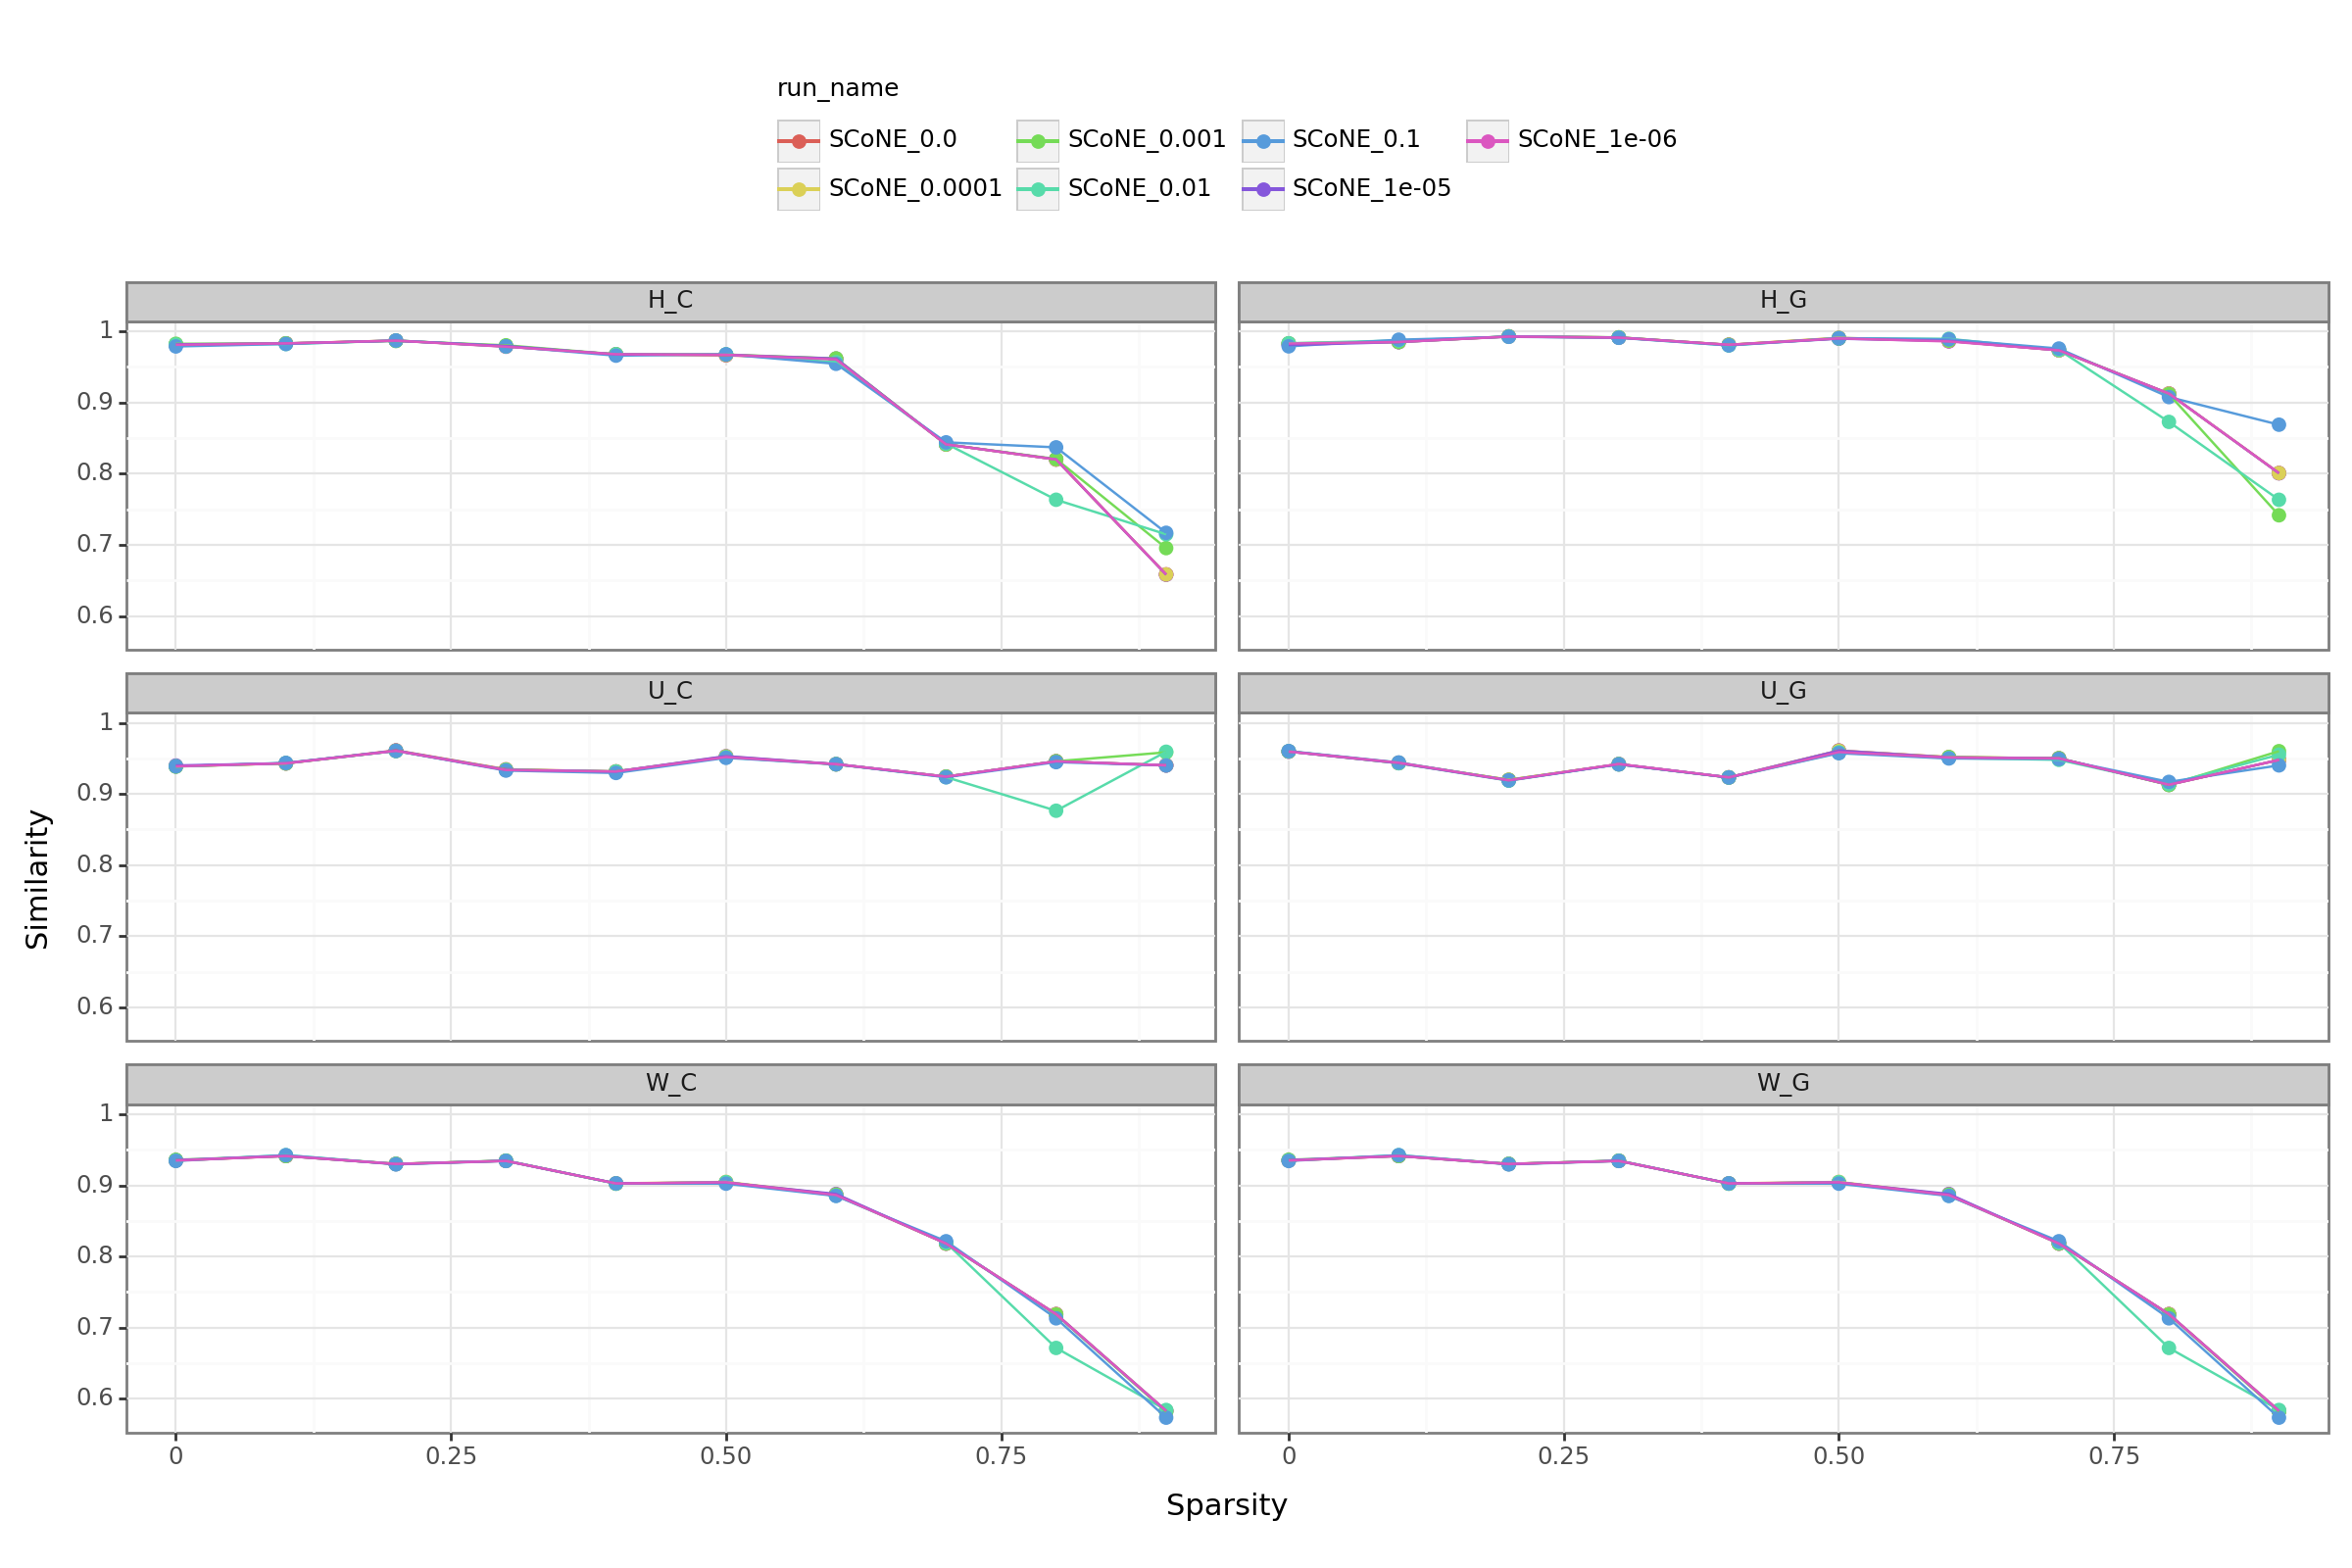

In [12]:
tuning_results = pd.read_csv("/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/sparsity_tuning_results.csv",index_col=0)
tuning_results = tuning_results[tuning_results['lambda_H_G']<1].copy()
tuning_results['run_name'] = tuning_results.apply(lambda x: x['run_name'] + '_' + str(x['lambda_H_G']),axis=1)
p = (
    ggplot(tuning_results, aes("sparsity", "sim", color='run_name', group='run_name'))
    + geom_point(size=2)
    + geom_line()
    + facet_wrap('factor_matrix',nrow=3)
    + labs(y='Similarity',x="Sparsity")
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

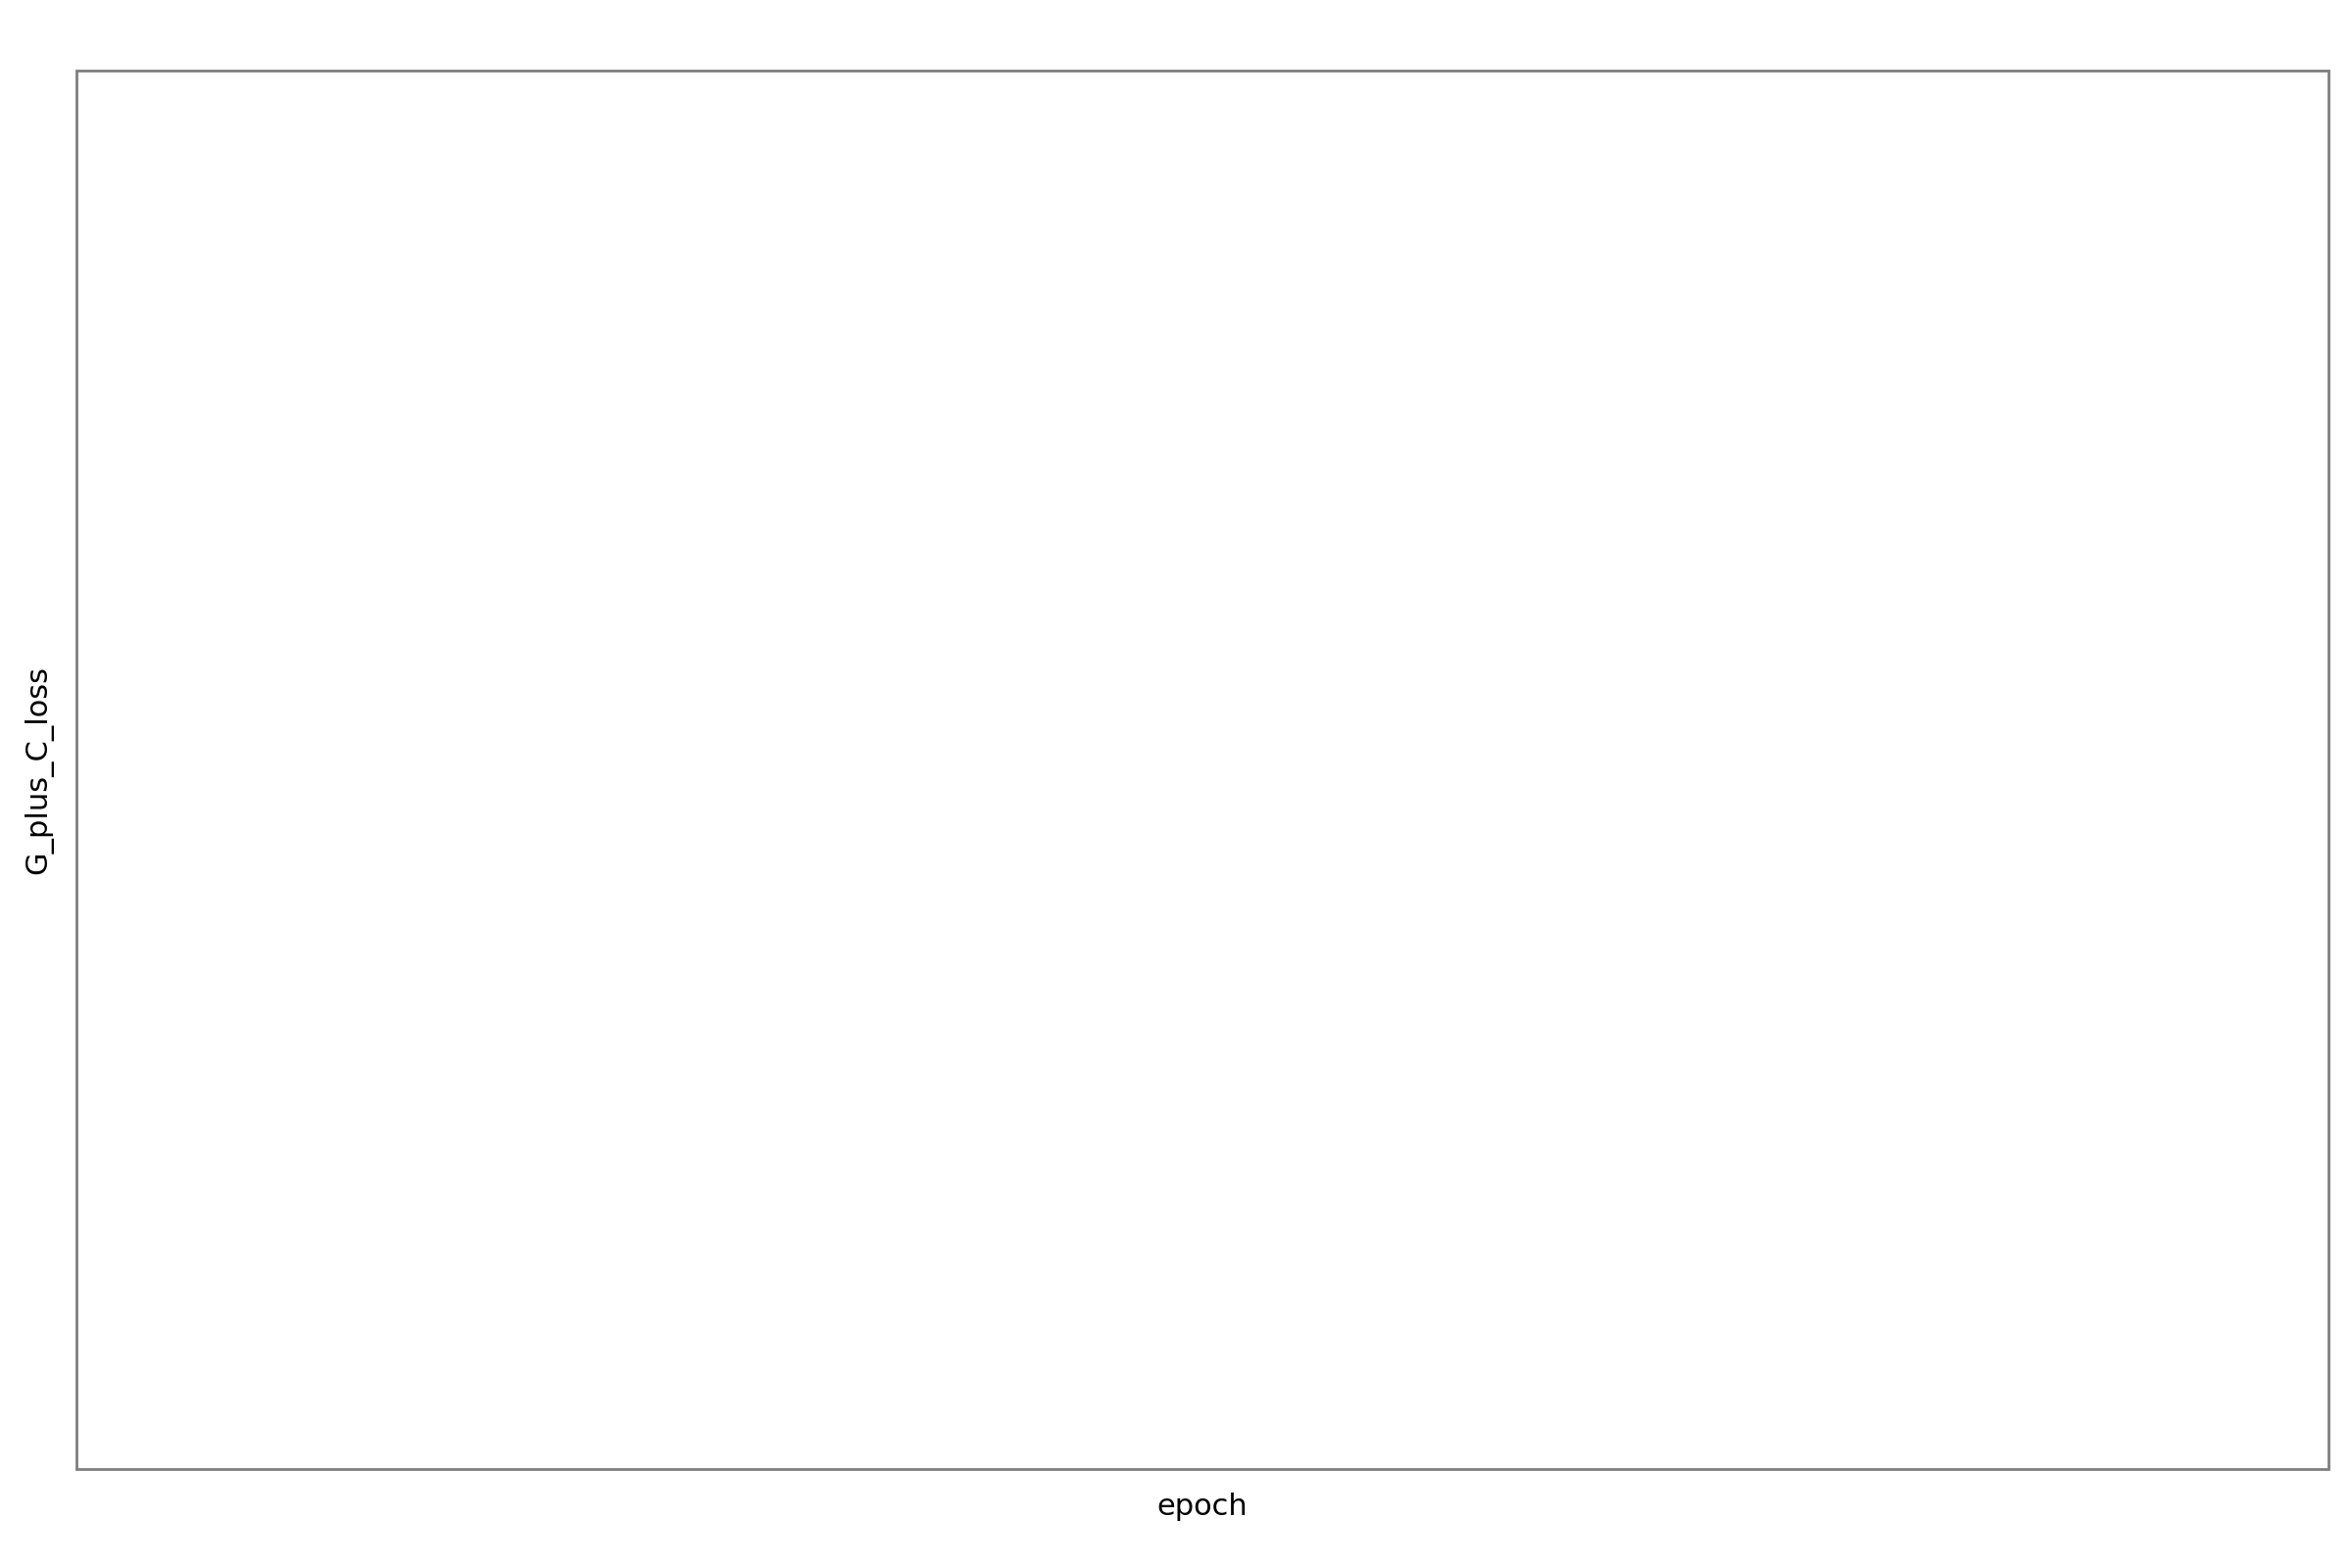

In [82]:
import json
import pandas as pd
import numpy as np
from plotnine import *
all_loss_functions = []
for lambda_val in [1e-6,1e-5,1e-4,1e-3,1e-2,1]:
    for sparsity in np.arange(0,1,0.1):
        with open(f"/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/models/loss_function_lambdaval_{lambda_val}_sparsity_{sparsity}.json","r") as f:
            loss_function = json.load(f)
            loss_function_df = pd.DataFrame(loss_function).reset_index(names='epoch')
            loss_function_df['lambda'] = str(lambda_val)
            loss_function_df['sparsity'] = sparsity
            all_loss_functions.append(loss_function_df)

all_loss_functions = pd.concat(all_loss_functions)
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.7], aes("epoch", "G_plus_C_loss", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

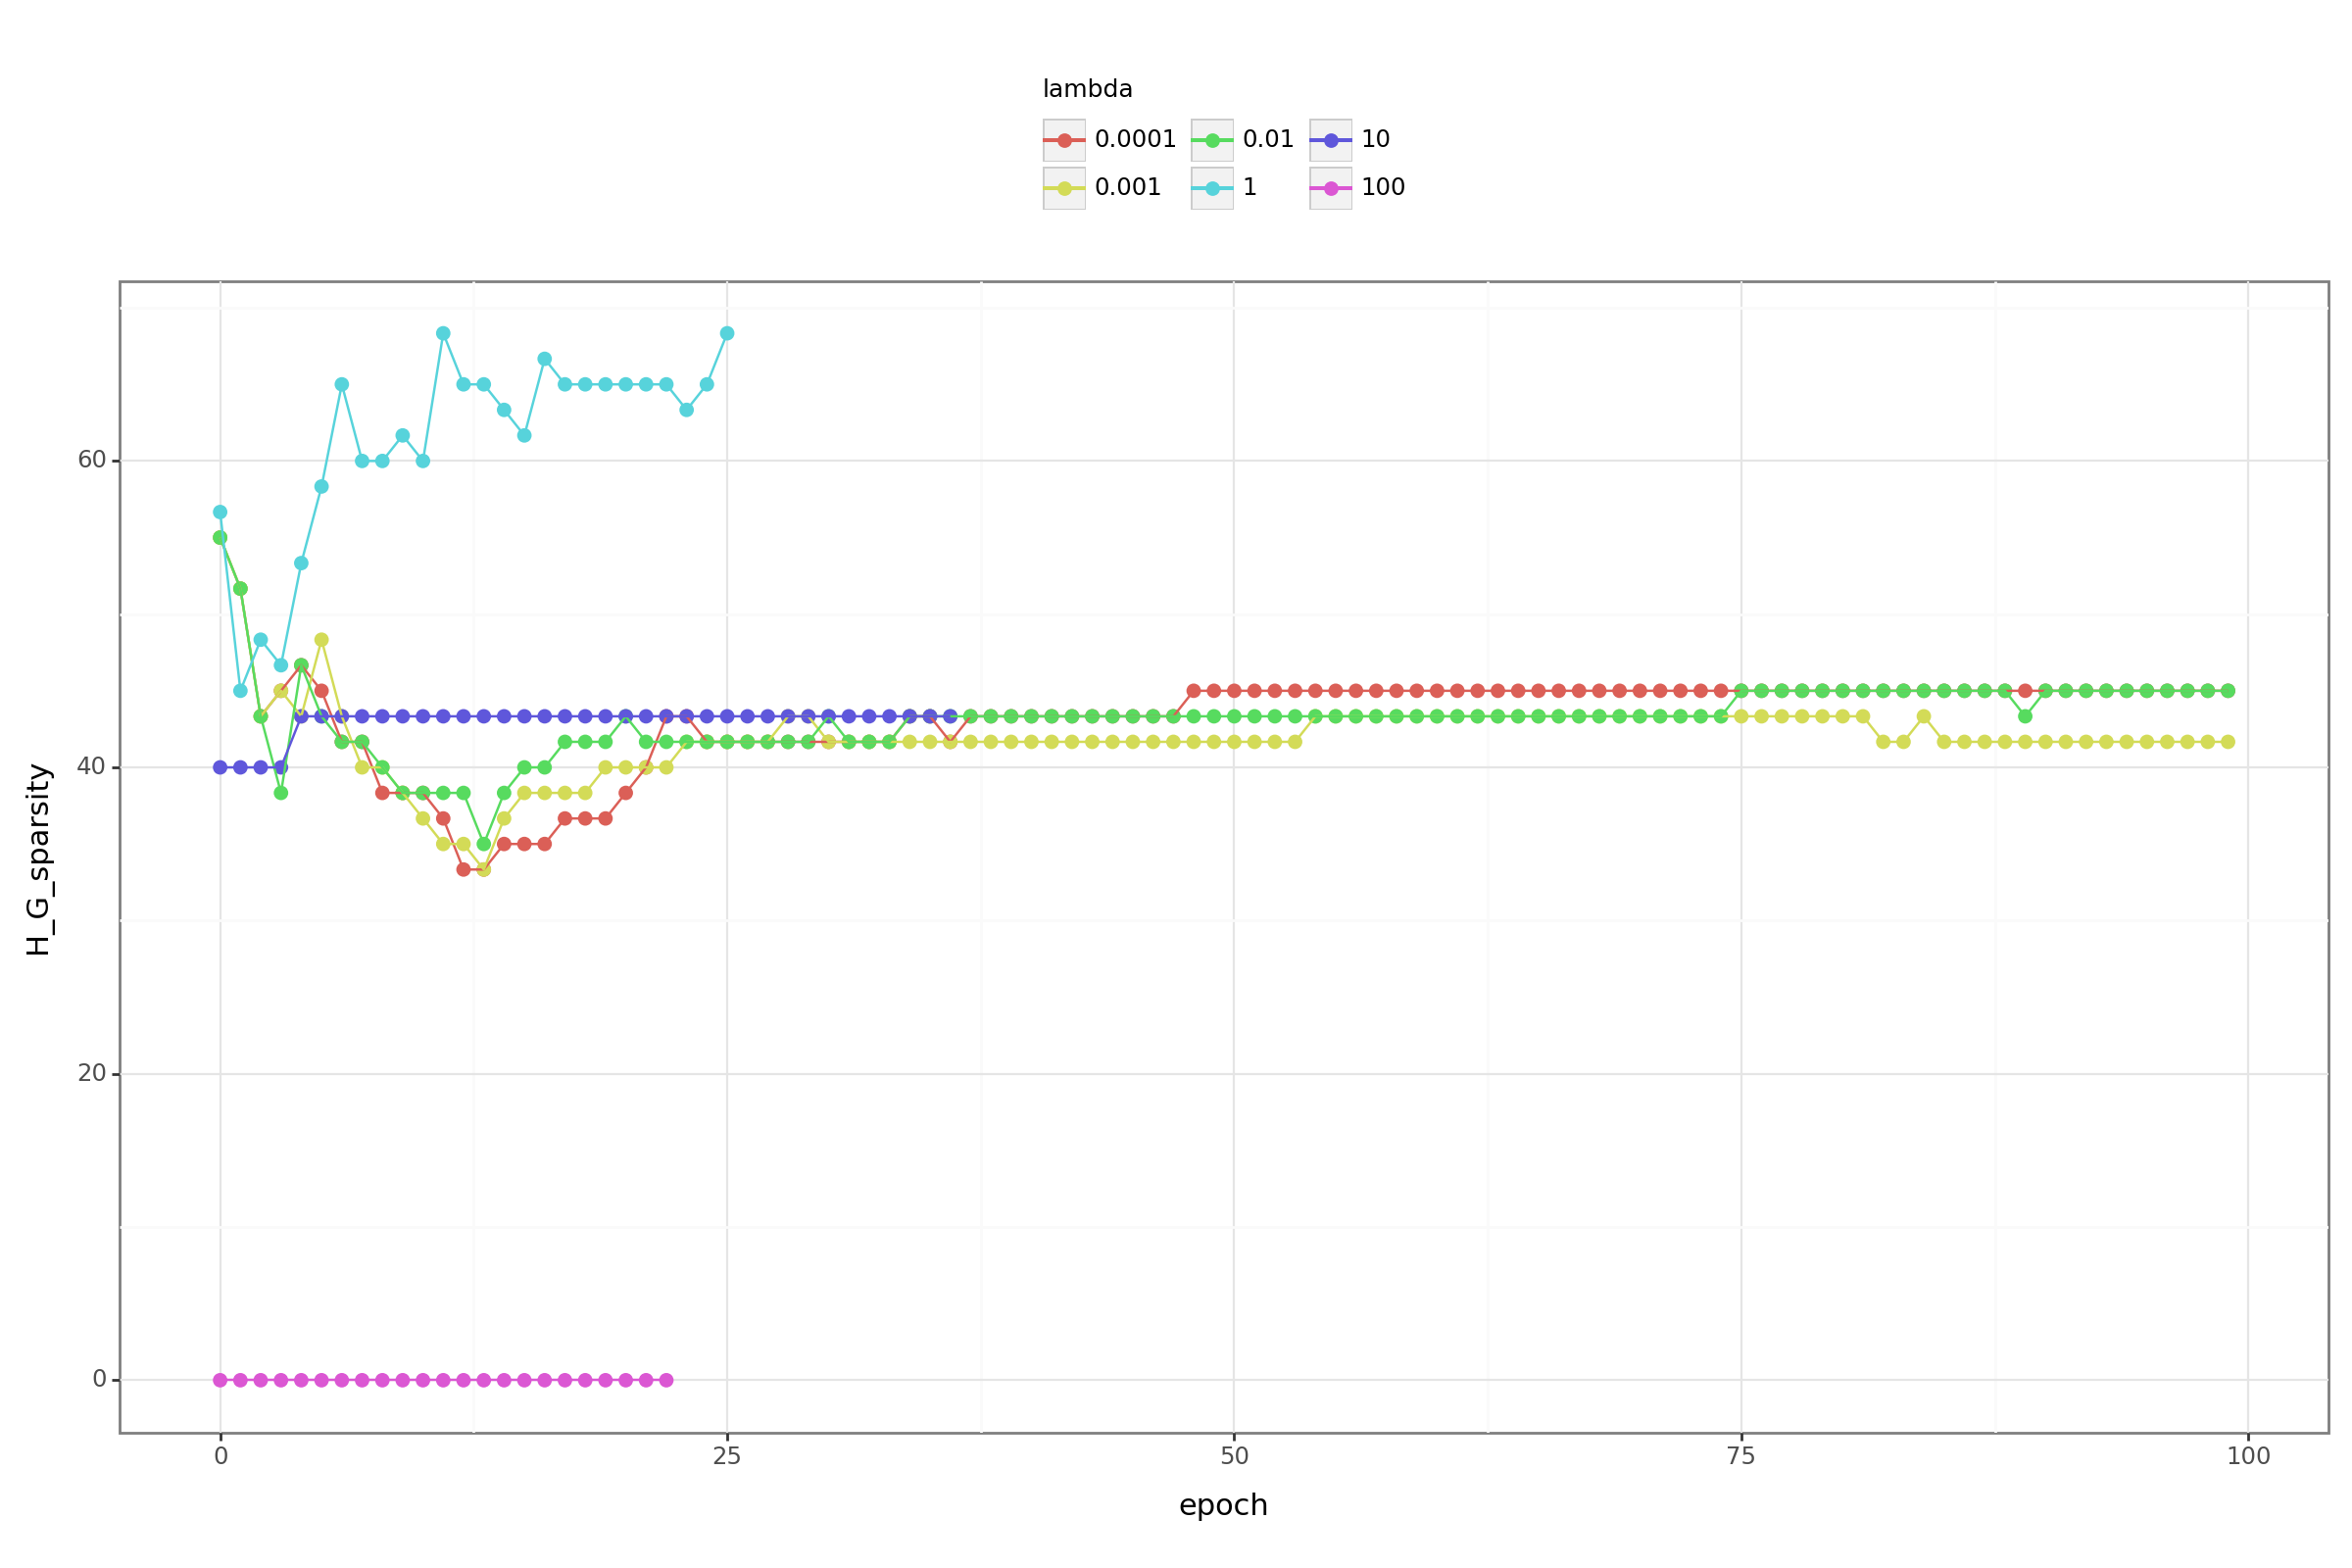

In [71]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "H_G_sparsity", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

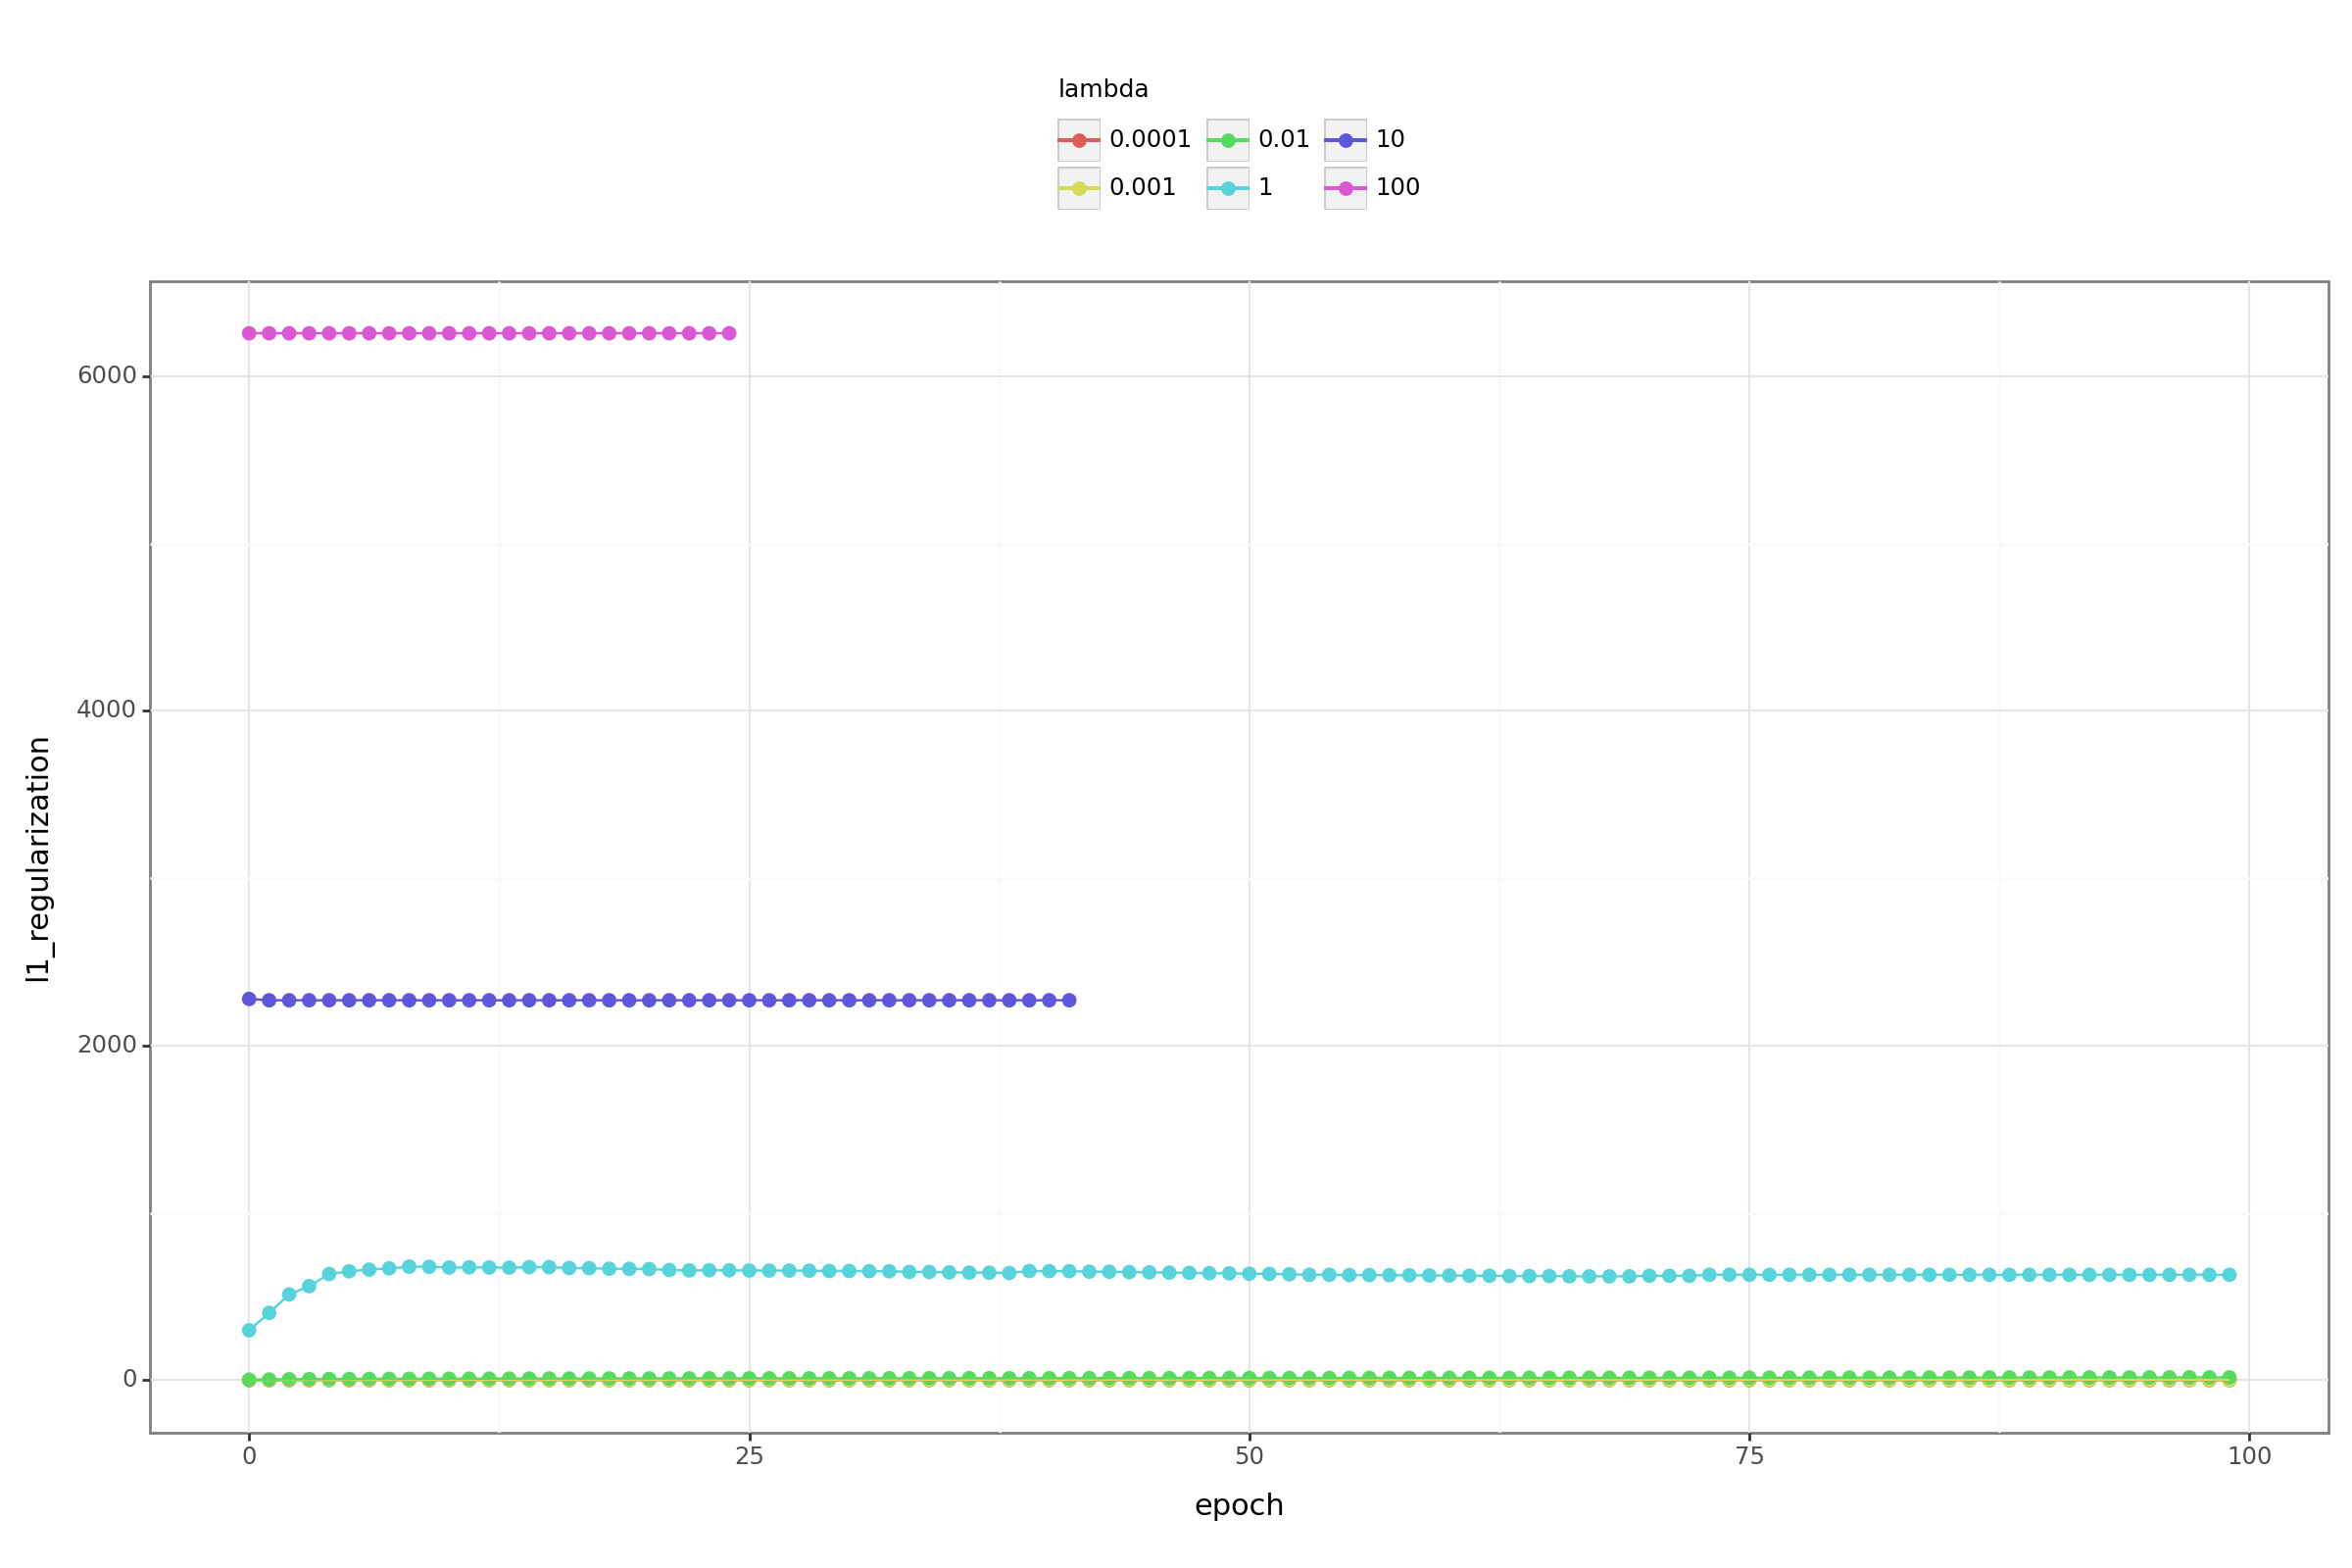

In [33]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "l1_regularization", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)

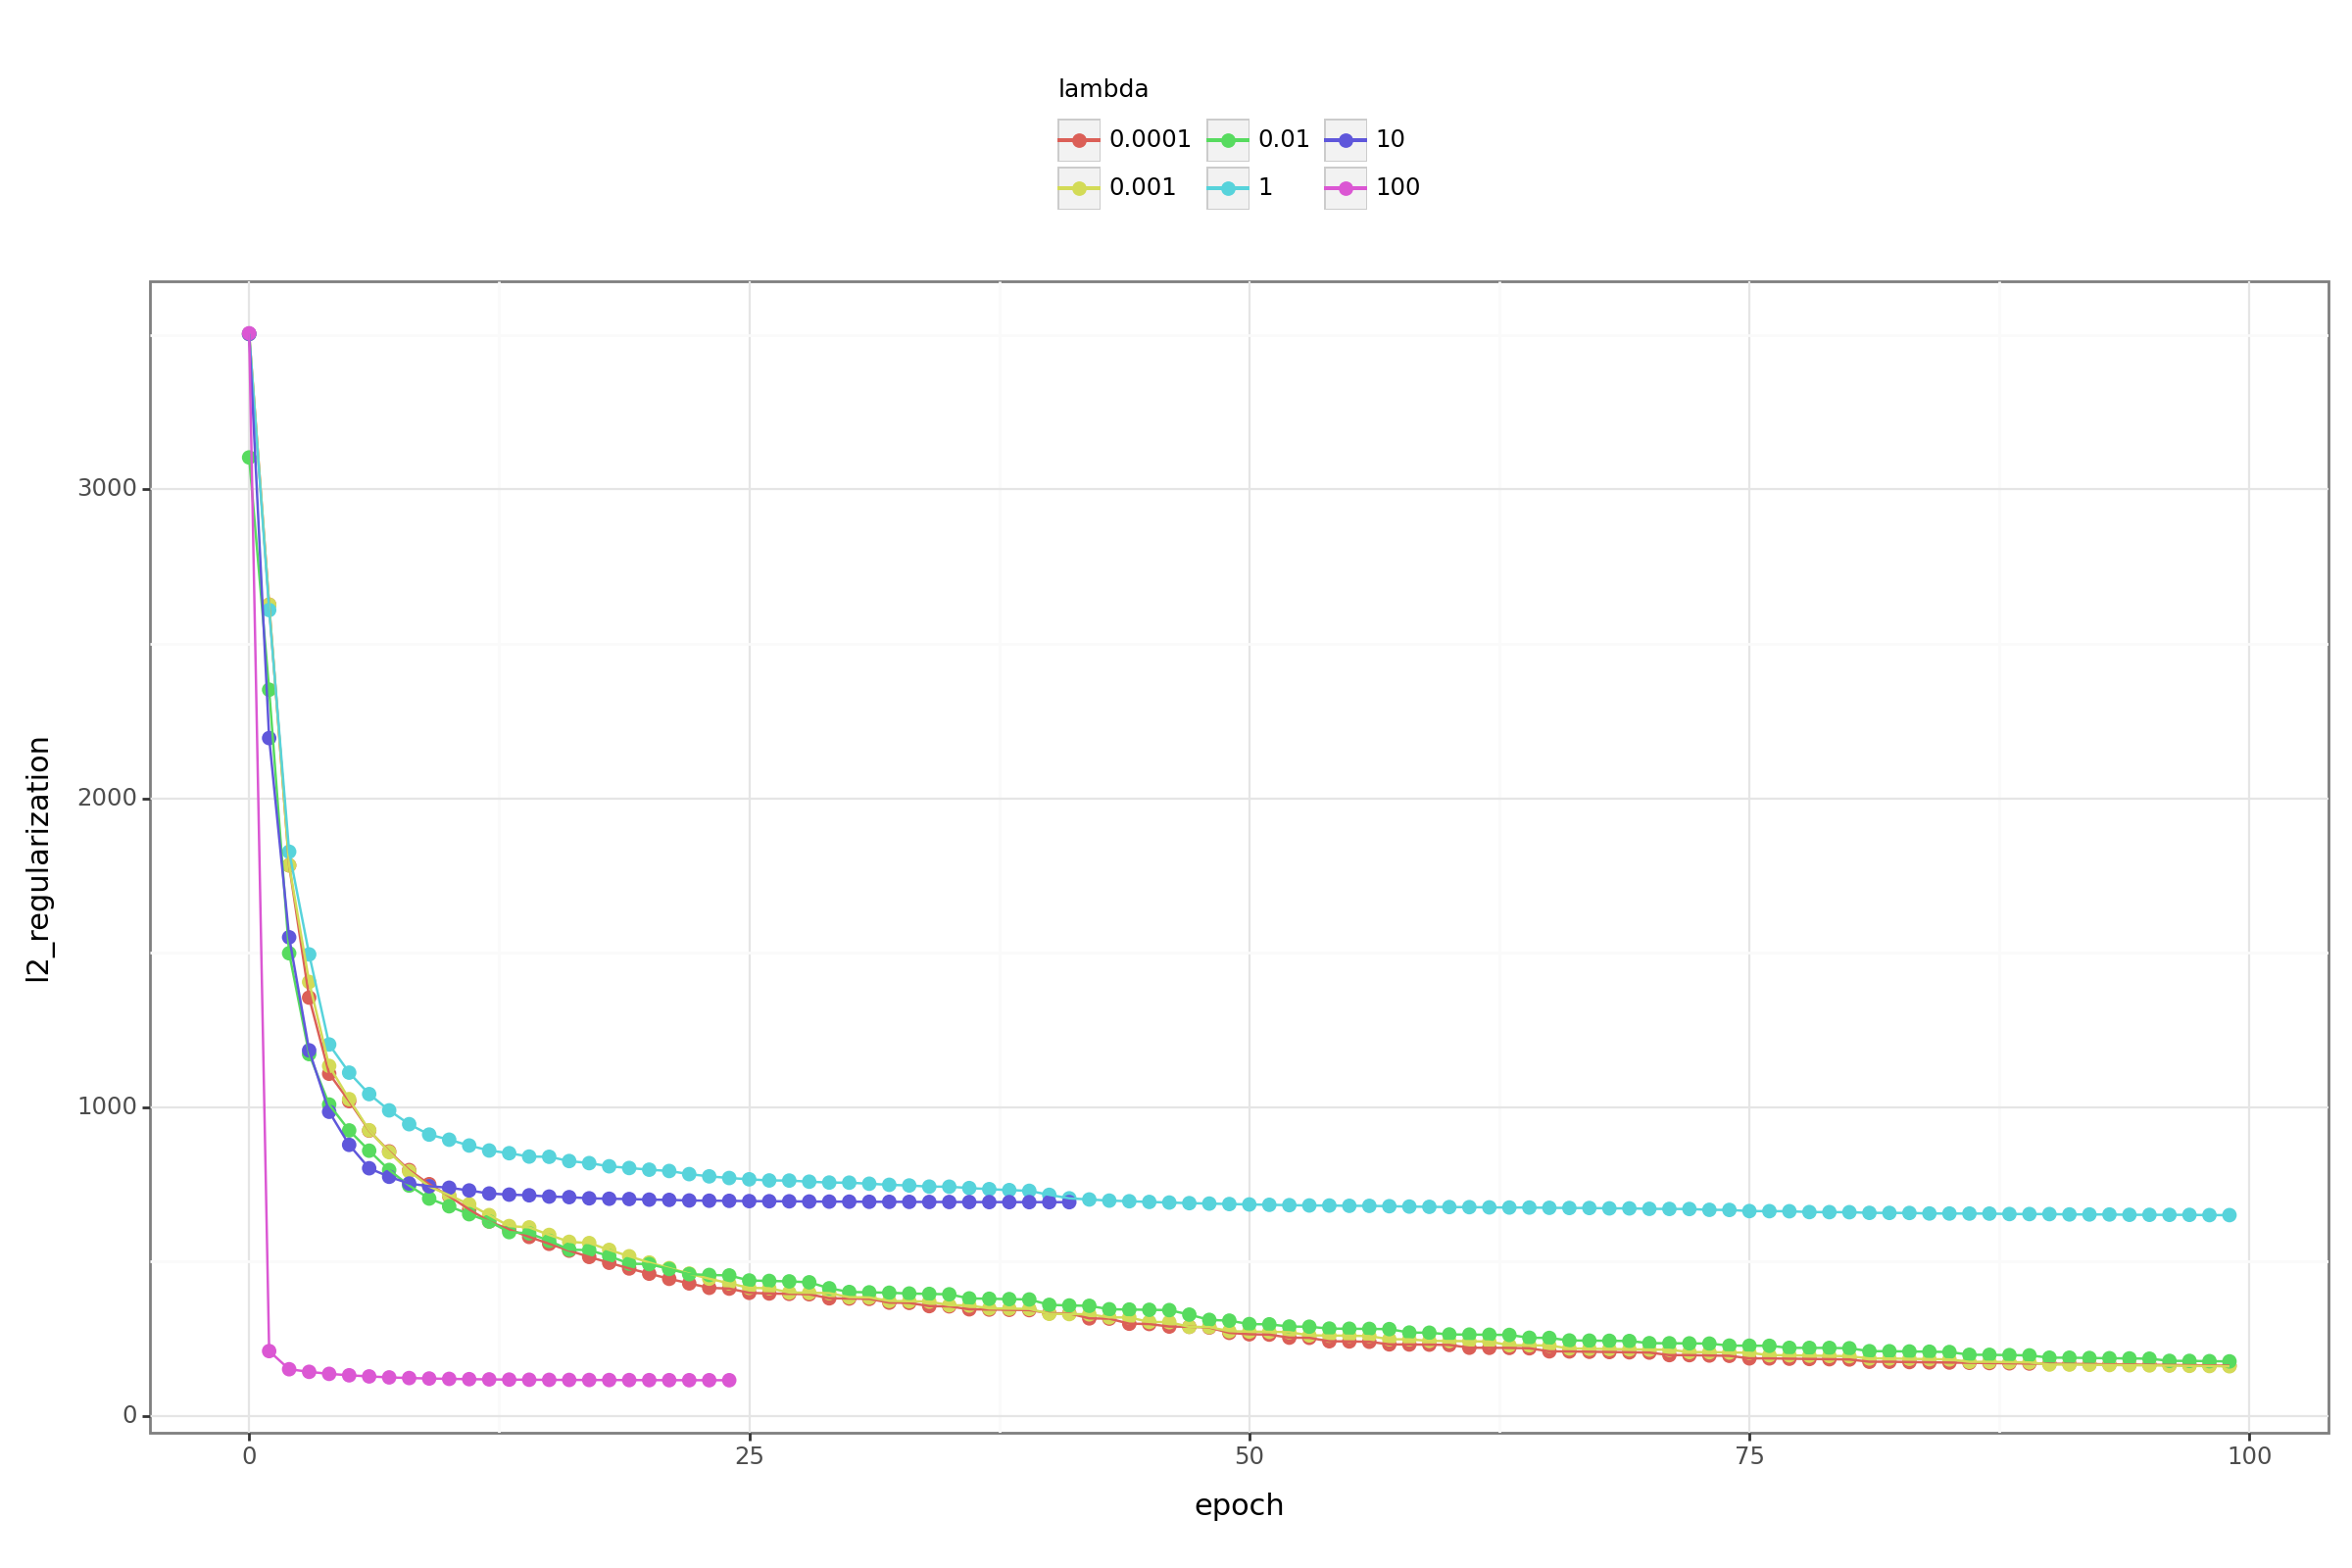

In [34]:
p = (
    ggplot(all_loss_functions[all_loss_functions['sparsity']==0.4], aes("epoch", "l2_regularization", color='lambda',group='lambda'))
    + geom_point(size=2)
    + geom_line()
    + theme_bw()
    + theme(legend_title=element_text(size=9),figure_size=(12,8),legend_position='top')
)
print(p)